In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ObesityDataSet1.csv")
output_df = pd.read_csv('result1_new.csv')
df_copy = df.copy()
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,NObeyesdad
0,Female,21.0,1.62,64.0,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,Normal_Weight
1,Female,21.0,1.52,56.0,yes,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Normal_Weight
2,Male,23.0,1.80,77.0,yes,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Normal_Weight
3,Male,27.0,1.80,87.0,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Overweight_Level_II


In [3]:
output_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE
0,Female,21.521294,1.803677,160.639405,yes,3,3,Sometimes,no,2.404049,no,0.427905,0.639894
1,Female,18.314593,1.745602,133.554686,yes,3,3,Sometimes,no,2.923792,no,1.536555,0.625350
2,Female,19.529746,1.751038,133.843033,yes,3,4,Sometimes,no,2.955075,no,1.460460,0.655558
3,Female,26.000000,1.631547,111.588625,yes,2,4,Sometimes,no,2.554007,no,0.000000,0.252635
4,Female,26.000000,1.635905,111.571076,yes,2,4,Sometimes,no,2.511399,no,0.000000,0.258472


# 1，数据探索

## 数据分析

In [4]:
print('数据大小:', df.shape)
print('表头:', df.columns)
print('数据信息:', df.info())
print(df.apply(lambda col: col.unique()))
df.nunique()
value=len(df[df.duplicated()])
print("数据集缺失数据：\n",df.isnull().sum())
print("数据集重复数据：\n",value)


数据大小: (1910, 14)
表头: Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'NObeyesdad'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          1910 non-null   object 
 1   Age                             1910 non-null   float64
 2   Height                          1910 non-null   float64
 3   Weight                          1910 non-null   float64
 4   family_history_with_overweight  1910 non-null   object 
 5   FCVC                            1910 non-null   float64
 6   NCP                             1910 non-null   float64
 7   CAEC                            1910 non-null   object 
 8   SMOKE                           1910 non-null   object 
 9   CH2O  

## 1)查看原始数据集中的目标列（0be1dad）并对目标列进行频率分析，查看各类别的样本数量并导出样本数量。

In [5]:
counts = df['NObeyesdad'].value_counts()
print(counts)
counts.to_csv('1.1_NObeyesdad_counts.csv')

NObeyesdad
Obesity_Type_I         351
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Obesity_Type_III       123
Name: count, dtype: int64


## 2)查看原始数据集中的每日耗水量（CH2O）、运动频率（FAF）并统计计算这两项数据的均值、中位数、标准差、最小值和最大值。

In [6]:
stats = df[['CH2O', 'FAF']].describe()
print(stats)
stats.to_csv('1.2_stats_CH2O_FAF.csv')



              CH2O          FAF
count  1910.000000  1910.000000
mean      1.984376     1.046790
std       0.611621     0.854850
min       1.000000     0.000000
25%       1.549942     0.190686
50%       2.000000     1.000000
75%       2.378797     1.745551
max       3.000000     3.000000


## 3)需识别原始数据集中缺失值的数量，根据{列名:缺失值数量,...}格式进行保存。

In [7]:
# 计算每列的缺失值数量
missing_values = df.isnull().sum()
print(missing_values)
missing_values.to_csv('1.3_missing_values.csv')


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
NObeyesdad                        0
dtype: int64


## 4)需得到数据集中含有缺失值的行，并使用常数0填写缺失值。

In [8]:
# 找到含有缺失值的行
missing_rows = df[df.isnull().any(axis=1)]

# 打印结果
print(missing_rows)

# 使用0填写缺失值
df.fillna(0, inplace=True)


Empty DataFrame
Columns: [Gender, Age, Height, Weight, family_history_with_overweight, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, NObeyesdad]
Index: []


## 5)查看数据集并使用合理方法修正数据集中的错误和异常值。

In [9]:
from scipy import stats
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    df[col] = np.where(z_scores > 5, df[col].median(), df[col])  # 使用中位数填充异常值

## 6)查看数据集将其中的性别列用【0、1】替换，0be1dad 根据label_map中key顺序用数字0-6替换。

In [10]:
label_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Obesity_Type_I": 2,
    "Obesity_Type_II": 3,
    "Obesity_Type_III": 4,
    "Overweight_Level_I": 5,
    "Overweight_Level_II": 6
}
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
output_df['Gender'] = output_df['Gender'].map({'Female': 0, 'Male': 1})
df['NObeyesdad'] = df['NObeyesdad'].map(label_map)



## 7)查看数据集并删除其中的无用列及重复记录。

In [11]:
# 没有无用列
# 删除重复的记录
df = df.drop_duplicates()


## 8)查看数据集将除了性别的分类列都用one-hot编码替换。

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1885 entries, 0 to 1909
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          1885 non-null   int64  
 1   Age                             1885 non-null   float64
 2   Height                          1885 non-null   float64
 3   Weight                          1885 non-null   float64
 4   family_history_with_overweight  1885 non-null   object 
 5   FCVC                            1885 non-null   float64
 6   NCP                             1885 non-null   float64
 7   CAEC                            1885 non-null   object 
 8   SMOKE                           1885 non-null   object 
 9   CH2O                            1885 non-null   float64
 10  SCC                             1885 non-null   object 
 11  FAF                             1885 non-null   float64
 12  TUE                             1885 no

In [14]:
from sklearn.preprocessing import OneHotEncoder


# 选择需要进行one-hot编码的列
categorical_columns = ['family_history_with_overweight', 'CAEC', 'SMOKE', 'SCC']

combined_df = pd.concat([df, output_df])
# 对合并后的数据进行one-hot编码
combined_df_encoded = pd.get_dummies(combined_df)

# 将编码后的数据分回训练数据和测试数据
df_encoded = combined_df_encoded.iloc[:len(df)]
output_encoded = combined_df_encoded.iloc[len(df):]


## 9)使用原始数据集生成类别频率可视化柱状图。

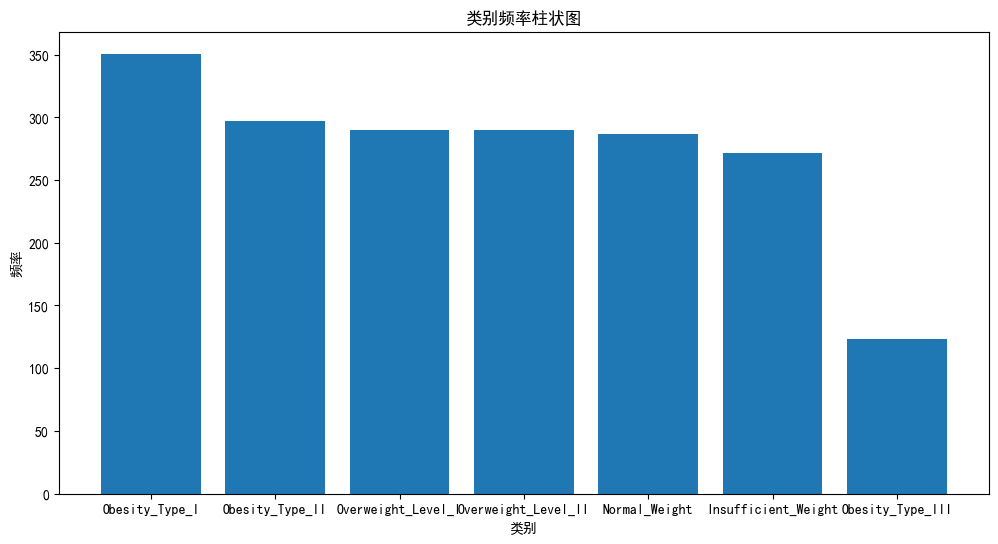

In [17]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)

# 添加标题和标签
plt.title('类别频率柱状图')
plt.xlabel('类别')
plt.ylabel('频率')

# 显示图形
plt.show()


## 10)使用原始数据集生成分布检查年龄的箱型图和直方图。

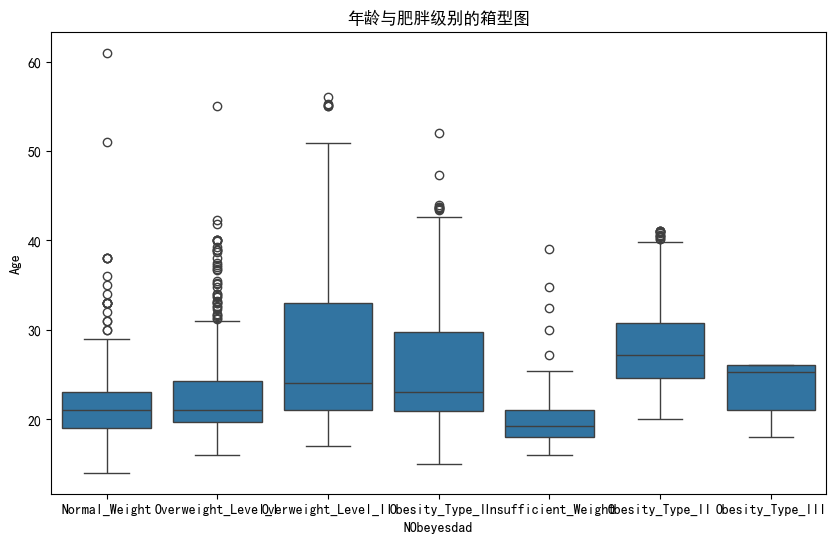

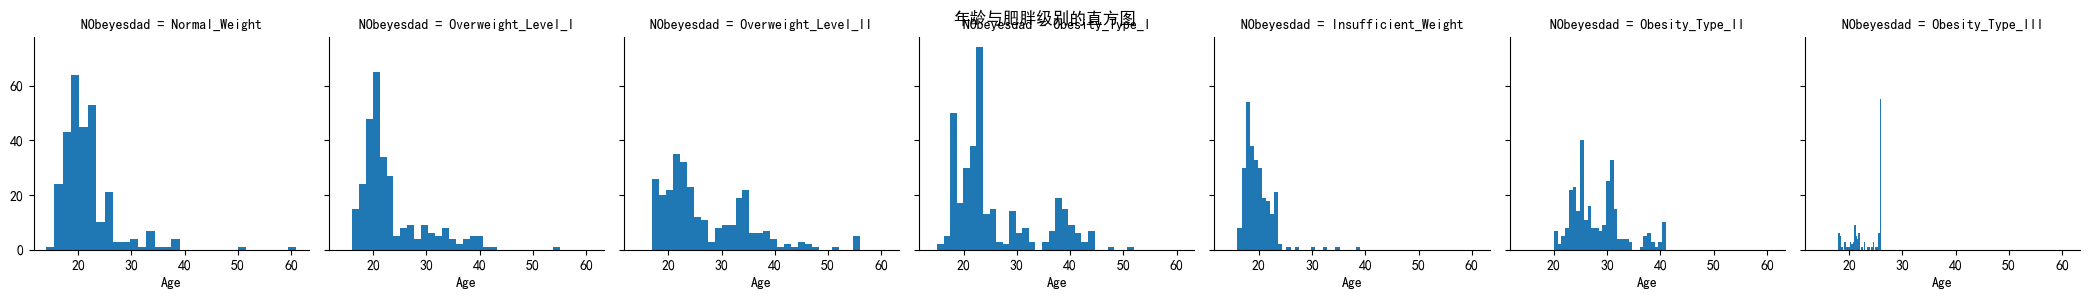

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建年龄的箱型图
plt.figure(figsize=(10, 6))
sns.boxplot(x='NObeyesdad', y='Age', data=df_copy)
plt.title('年龄与肥胖级别的箱型图')
plt.show()

# 创建年龄的直方图，按肥胖级别分组
g = sns.FacetGrid(df_copy, col='NObeyesdad')
g.map(plt.hist, 'Age', bins=30)
plt.suptitle('年龄与肥胖级别的直方图')
plt.show()


## 11)使用任务一中处理好的数据集生成反映不同特征条件下的肥胖情况热力图。

C:\Users\32950\AppData\Roaming\Python\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\32950\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


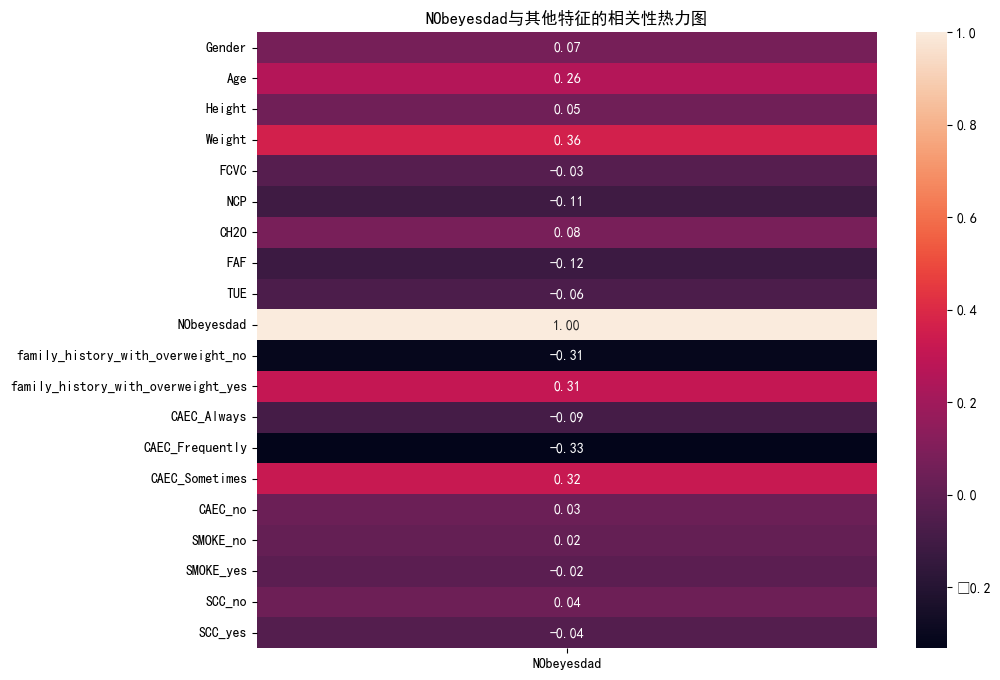

C:\Users\32950\AppData\Roaming\Python\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\32950\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


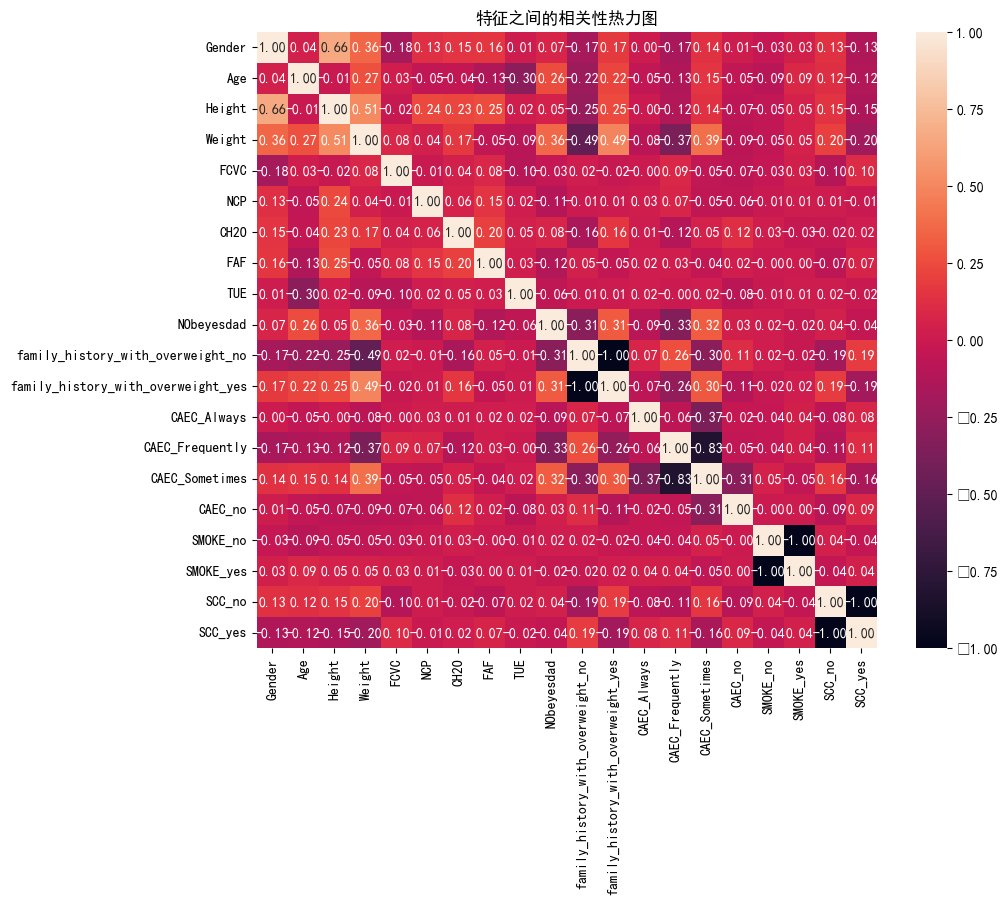

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()[['NObeyesdad']]

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('NObeyesdad与其他特征的相关性热力图')
plt.show()



corr = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('特征之间的相关性热力图')
plt.show()


## 12)使用任务一中处理好的数据集按照8：2将数据集拆分为训练集和测试集并生成可视化数据集柱状图。

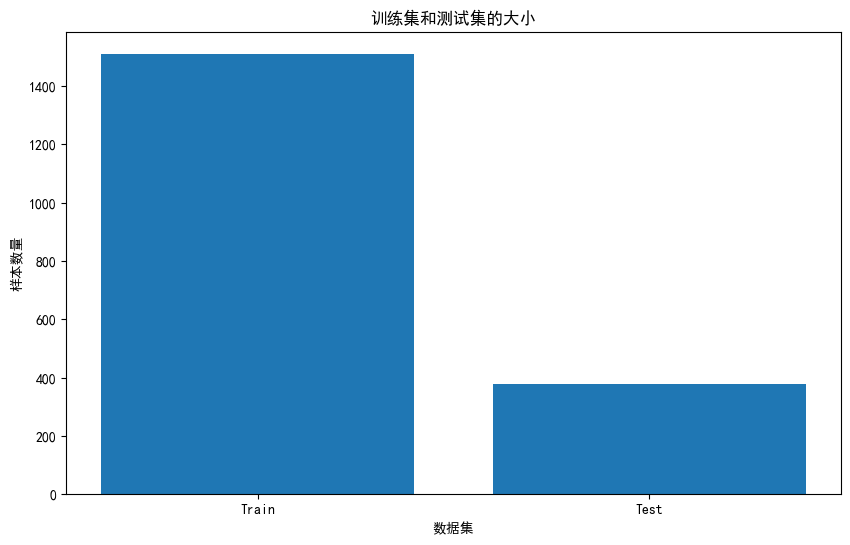

In [20]:
from sklearn.model_selection import train_test_split

y = df_encoded.pop('NObeyesdad')
X = df_encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(10, 6))
plt.bar(['Train', 'Test'], [len(y_train), len(y_test)])
plt.title('训练集和测试集的大小')
plt.xlabel('数据集')
plt.ylabel('样本数量')
plt.show()



# 二，数据分析与挖掘

## （1）使用任务一中处理好的数据集对数据进行标准化处理。

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)




In [27]:
output_encoded.pop('NObeyesdad')

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
195   NaN
196   NaN
197   NaN
198   NaN
199   NaN
Name: NObeyesdad, Length: 200, dtype: float64

In [28]:
output_encoded  = scaler.transform(output_encoded)
output_encoded  = pd.DataFrame(output_encoded, columns=X_train.columns)


## （2）使用任务一中处理好的数据集生成训练日志。

### 特征筛选

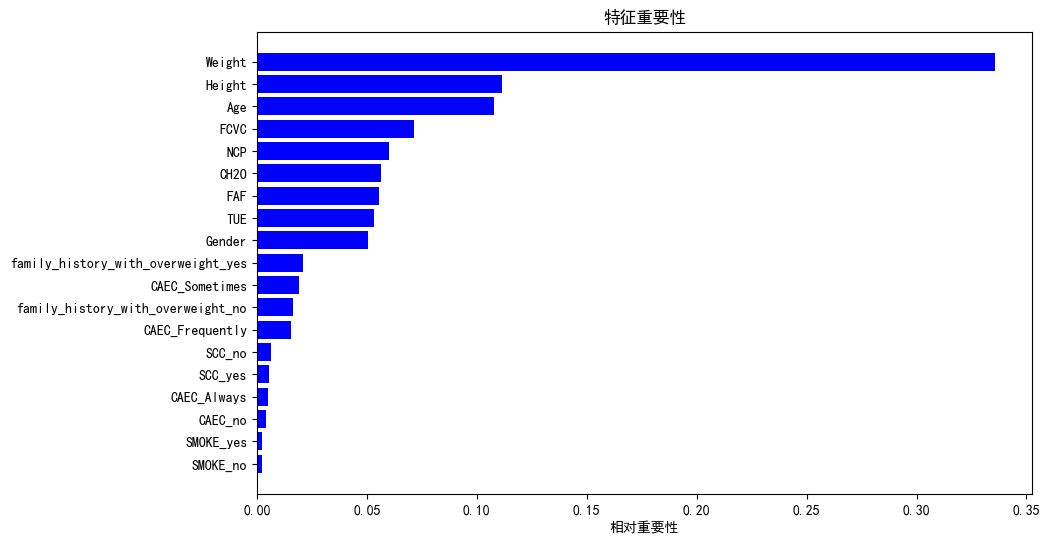

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier()
clf.fit(X_train_scaled, y_train)
# selector = SelectFromModel(clf, prefit=True)
# X_train_selected = selector.transform(X_train_scaled)
# selected_features = selector.get_support(indices=True)

# print(f'Selected features: {X_train.columns[selected_features]}')


# 获取特征重要性
importances = clf.feature_importances_

# 将特征重要性排序并获取索引
indices = np.argsort(importances)

# 创建绘图
plt.figure(figsize=(10, 6))
plt.title('特征重要性')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('相对重要性')
plt.show()



In [32]:
X_train_scaled.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF',
       'TUE', 'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'CAEC_Always', 'CAEC_Frequently',
       'CAEC_Sometimes', 'CAEC_no', 'SMOKE_no', 'SMOKE_yes', 'SCC_no',
       'SCC_yes'],
      dtype='object')

In [34]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

selected_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF','TUE','Gender','family_history_with_overweight_no','family_history_with_overweight_yes','CAEC_Sometimes','CAEC_Frequently']
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features]
# 定义模型
models = [
    ('Random Forest', RandomForestClassifier()),
    ('SVM', SVC()),
    ('Logistic Regression', LogisticRegression()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('Neural Network', MLPClassifier())
]

# 对每个模型进行训练和测试
for name, model in models:
    # 训练模型
    model.fit(X_train_scaled_selected, y_train)
    
    # 在测试集上进行预测
    y_pred = model.predict(X_test_scaled_selected)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    
    # 打印结果
    print(f'{name} Accuracy: {accuracy}')


Random Forest Accuracy: 0.946949602122016
SVM Accuracy: 0.883289124668435
Logistic Regression Accuracy: 0.8726790450928382
Gradient Boosting Accuracy: 0.9602122015915119
Neural Network Accuracy: 0.9363395225464191


C:\Users\32950\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [59]:
from sklearn.model_selection import GridSearchCV
output_encoded
# rf超参搜索
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

clf = RandomForestClassifier()
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled_selected, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')


Best parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Best score: 0.93966469384612


In [40]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
lst_logs = []

clf.fit(X_train_scaled, y_train)

# 在训练集上预测
train_preds = clf.predict(X_train_scaled)
train_proba = clf.predict_proba(X_train_scaled)

# 计算训练集的准确率和损失
train_acc = accuracy_score(y_train, train_preds)
train_loss = log_loss(y_train, train_proba)

# 打印训练集的准确率和损失
print(f'No select Train Accuracy: {train_acc}')
print(f'No select Train Loss: {train_loss}')
lst_logs.append(f'No select Train Accuracy: {train_acc}')
lst_logs.append(f'No select Train Loss: {train_loss}')

# 在测试集上预测
test_preds = clf.predict(X_test_scaled)
test_proba = clf.predict_proba(X_test_scaled)

# 计算测试集的准确率和损失
test_acc = accuracy_score(y_test, test_preds)
test_loss = log_loss(y_test, test_proba)

# 打印测试集的准确率和损失
print(f'No select Test Accuracy: {test_acc}')
print(f'No select Test Loss: {test_loss}')
lst_logs.append(f'No select Test Accuracy: {test_acc}')
lst_logs.append(f'No select Test Loss: {test_loss}')


No select Train Accuracy: 1.0
No select Train Loss: 0.09051697639205364
No select Test Accuracy: 0.9416445623342176
No select Test Loss: 0.30069527553515607


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
params = {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

clf = RandomForestClassifier(max_depth=params['max_depth'], min_samples_split=params['min_samples_split'], n_estimators=params['n_estimators'])


clf.fit(X_train_scaled_selected, y_train)

# 在训练集上预测
train_preds = clf.predict(X_train_scaled_selected)
train_proba = clf.predict_proba(X_train_scaled_selected)

# 计算训练集的准确率和损失
train_acc = accuracy_score(y_train, train_preds)
train_loss = log_loss(y_train, train_proba)

# 打印训练集的准确率和损失
print(f' select Train Accuracy: {train_acc}')
print(f' select Train Loss: {train_loss}')
lst_logs.append(f' select Train Accuracy: {train_acc}')
lst_logs.append(f' select Train Loss: {train_loss}')

# 在测试集上预测
test_preds = clf.predict(X_test_scaled_selected)
test_proba = clf.predict_proba(X_test_scaled_selected)

# 计算测试集的准确率和损失
test_acc = accuracy_score(y_test, test_preds)
test_loss = log_loss(y_test, test_proba)

# 打印测试集的准确率和损失
print(f' select Test Accuracy: {test_acc}')
print(f' select Test Loss: {test_loss}')
lst_logs.append(f' select Test Accuracy: {test_acc}')
lst_logs.append(f' select Test Loss: {test_loss}')


 select Train Accuracy: 0.9986737400530504
 select Train Loss: 0.14934682364214608
 select Test Accuracy: 0.9522546419098143
 select Test Loss: 0.31060807569497845


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
params = {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

clf = RandomForestClassifier(max_depth=params['max_depth'], min_samples_split=params['min_samples_split'], n_estimators=params['n_estimators'])

lst_logs = []

clf.fit(X_train_scaled, y_train)

# 在训练集上预测
train_preds = clf.predict(X_train_scaled)
train_proba = clf.predict_proba(X_train_scaled)

# 计算训练集的准确率和损失
train_acc = accuracy_score(y_train, train_preds)
train_loss = log_loss(y_train, train_proba)

# 打印训练集的准确率和损失
print(f' select Train Accuracy: {train_acc}')
print(f' select Train Loss: {train_loss}')
lst_logs.append(f' select Train Accuracy: {train_acc}')
lst_logs.append(f' select Train Loss: {train_loss}')

# 在测试集上预测
test_preds = clf.predict(X_test_scaled)
test_proba = clf.predict_proba(X_test_scaled)

# 计算测试集的准确率和损失
test_acc = accuracy_score(y_test, test_preds)
test_loss = log_loss(y_test, test_proba)

# 打印测试集的准确率和损失
print(f' select Test Accuracy: {test_acc}')
print(f' select Test Loss: {test_loss}')
lst_logs.append(f' select Test Accuracy: {test_acc}')
lst_logs.append(f' select Test Loss: {test_loss}')


 select Train Accuracy: 0.9973474801061007
 select Train Loss: 0.15330900052321983
 select Test Accuracy: 0.9496021220159151
 select Test Loss: 0.31353855834981426


## （3）使用任务一中处理好的数据集生成模型文件。

In [43]:
import pickle

# 保存模型
with open('model.pkl', 'wb') as f:
    pickle.dump(clf, f)


# 三，调参与优化

## （1）使用上述任务中划分好的测试集加载模型并使用测试集进行评估，保存格式为{类别:{指标键值对},...,"accuracy":0.00}。

In [44]:
from sklearn.metrics import classification_report
import json


y_pred = clf.predict(X_test_scaled)

# 生成分类报告
report = classification_report(y_test, y_pred, output_dict=True)
report['accuracy'] = accuracy_score(y_test, y_pred)

print(report)


with open('3.1_report.json', 'w') as f:
    json.dump(report, f)


{'0.0': {'precision': 0.9629629629629629, 'recall': 0.9285714285714286, 'f1-score': 0.9454545454545454, 'support': 56.0}, '1.0': {'precision': 0.7941176470588235, 'recall': 0.9473684210526315, 'f1-score': 0.864, 'support': 57.0}, '2.0': {'precision': 1.0, 'recall': 0.975609756097561, 'f1-score': 0.9876543209876543, 'support': 82.0}, '3.0': {'precision': 0.9846153846153847, 'recall': 1.0, 'f1-score': 0.9922480620155039, 'support': 64.0}, '4.0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 23.0}, '5.0': {'precision': 0.9782608695652174, 'recall': 0.8823529411764706, 'f1-score': 0.9278350515463918, 'support': 51.0}, '6.0': {'precision': 0.975609756097561, 'recall': 0.9090909090909091, 'f1-score': 0.9411764705882353, 'support': 44.0}, 'accuracy': 0.9496021220159151, 'macro avg': {'precision': 0.9565095171857071, 'recall': 0.9489990651412858, 'f1-score': 0.9511954929417615, 'support': 377.0}, 'weighted avg': {'precision': 0.9549712202646743, 'recall': 0.9496021220159151, 'f

## （2）将模型评估结果绘制Precision、Recall、F1-score曲线。

In [45]:
label_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Obesity_Type_I": 2,
    "Obesity_Type_II": 3,
    "Obesity_Type_III": 4,
    "Overweight_Level_I": 5,
    "Overweight_Level_II": 6
}

id2label =  {v: k for k, v in label_map.items()}

# 打印新的字典
print(id2label)


{0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}


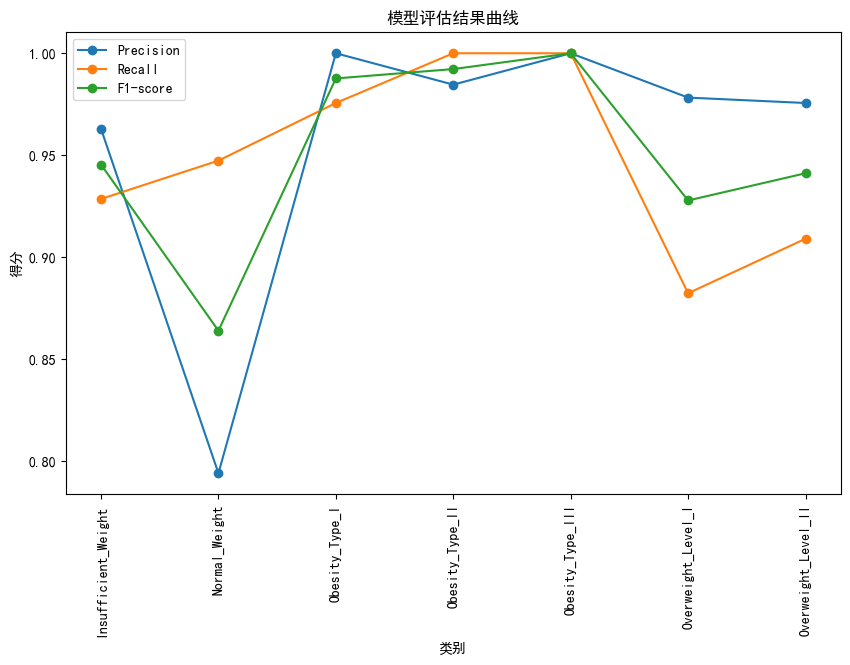

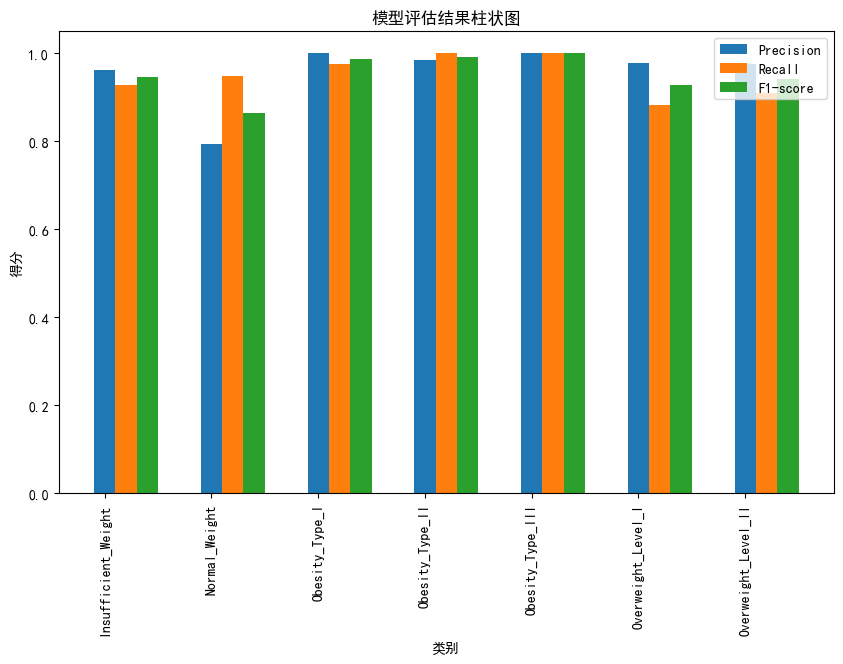

In [47]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

y_test_labels = [id2label[id] for id in y_test]
y_pred_labels = [id2label[id] for id in y_pred]

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test_labels, y_pred_labels, average=None)

labels = np.unique(y_test_labels + y_pred_labels)


plt.figure(figsize=(10, 6))
x = np.arange(len(labels))
plt.plot(x, precision, marker='o', label='Precision')
plt.plot(x, recall, marker='o', label='Recall')
plt.plot(x, f1_score, marker='o', label='F1-score')

plt.title('模型评估结果曲线')
plt.xlabel('类别')
plt.ylabel('得分')
plt.xticks(ticks=x, labels=labels, rotation=90)  # 将x轴的标签替换为类别的标签
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
x = np.arange(len(labels))
plt.bar(x, precision, width=0.2, label='Precision')
plt.bar(x + 0.2, recall, width=0.2, label='Recall')
plt.bar(x + 0.4, f1_score, width=0.2, label='F1-score')
plt.title('模型评估结果柱状图')
plt.xlabel('类别')
plt.ylabel('得分')
plt.xticks(ticks=x, labels=labels, rotation=90)  # 将x轴的标签替换为类别的标签
plt.legend()

# 显示图形
plt.show()

## 3）使用验证集（result.csv）加载模型并给出预测结果TARGET列，保存为新的csv文件。

In [48]:
y_valid_pred = clf.predict(output_encoded)


In [53]:
y_test_labels = [id2label[id] for id in y_valid_pred]


In [57]:
output_df['predict_Obe'] = y_test_labels
output_df.to_csv('result.csv')

见 二-（2）

In [58]:
output_df

,Gender,Age,Height,Weight,family_history_with_overweight,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,predict_Obe
0,0,21.521294,1.803677,160.639405,yes,3,3,Sometimes,no,2.404049,no,0.427905,0.639894,Obesity_Type_III
1,0,18.314593,1.745602,133.554686,yes,3,3,Sometimes,no,2.923792,no,1.536555,0.625350,Obesity_Type_III
2,0,19.529746,1.751038,133.843033,yes,3,4,Sometimes,no,2.955075,no,1.460460,0.655558,Obesity_Type_III
3,0,26.000000,1.631547,111.588625,yes,2,4,Sometimes,no,2.554007,no,0.000000,0.252635,Obesity_Type_III
4,0,26.000000,1.635905,111.571076,yes,2,4,Sometimes,no,2.511399,no,0.000000,0.258472,Obesity_Type_III
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,21.285965,1.726920,131.335786,yes,3,3,Sometimes,no,1.796267,no,1.728332,0.897924,Obesity_Type_III
196,0,20.976842,1.710730,131.408528,yes,3,3,Sometimes,no,1.728139,no,1.676269,0.906247,Obesity_Type_III
197,0,21.982942,1.748584,133.742943,yes,3,3,Sometimes,no,2.005130,no,1.341390,0.599270,Obesity_Type_III
198,0,22.524036,1.752206,133.689352,yes,3,3,Sometimes,no,2.054193,no,1.414209,0.646288,Obesity_Type_III
